In [1]:
import sys
sys.path.append("../")

from src.preprocessing import (
    load_data,
    create_target,
    handle_missing_values,
    check_class_balance,
    save_processed_data
)

In [2]:
df = load_data("../data/raw/credit_data.csv")
df = create_target(df)
df = handle_missing_values(df)

check_class_balance(df)

save_processed_data(df, "../data/processed/credit_data_clean.csv")

df.head()

Total Missing Values in Dataset: 0
Class Distribution:
default
1    0.7
0    0.3
Name: proportion, dtype: float64


,status,duration,credit_history,purpose,amount,savings,employment_duration,installment_rate,personal_status_sex,other_debtors,...,age,other_installment_plans,housing,number_credits,job,people_liable,telephone,foreign_worker,credit_risk,default
0,... < 100 DM,6,critical account/other credits existing,domestic appliances,1169,unknown/no savings account,... >= 7 years,4,male : single,none,...,67,none,own,2,skilled employee/official,1,yes,yes,1,1
1,0 <= ... < 200 DM,48,existing credits paid back duly till now,domestic appliances,5951,... < 100 DM,1 <= ... < 4 years,2,female : divorced/separated/married,none,...,22,none,own,1,skilled employee/official,1,no,yes,0,0
2,no checking account,12,critical account/other credits existing,retraining,2096,... < 100 DM,4 <= ... < 7 years,2,male : single,none,...,49,none,own,1,unskilled - resident,2,no,yes,1,1
3,... < 100 DM,42,existing credits paid back duly till now,radio/television,7882,... < 100 DM,4 <= ... < 7 years,2,male : single,guarantor,...,45,none,for free,1,skilled employee/official,2,no,yes,1,1
4,... < 100 DM,24,delay in paying off in the past,car (new),4870,... < 100 DM,1 <= ... < 4 years,3,male : single,none,...,53,none,for free,2,skilled employee/official,2,no,yes,0,0


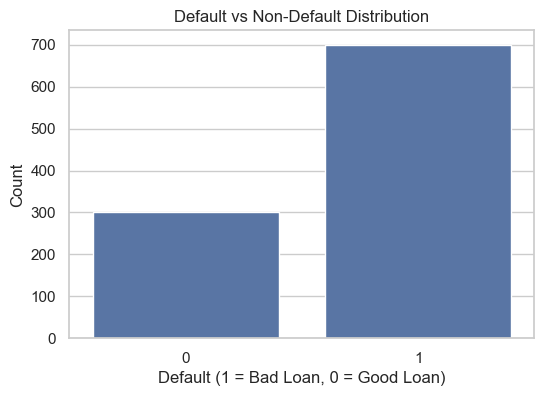

In [4]:
import matplotlib.pyplot as plt
import seaborn as sns

sns.set(style="whitegrid")

plt.figure(figsize=(6,4))
sns.countplot(x='default', data=df)
plt.title("Default vs Non-Default Distribution")
plt.xlabel("Default (1 = Bad Loan, 0 = Good Loan)")
plt.ylabel("Count")
plt.show()

### Insight:
Approximately 70% of loans in the dataset are classified as default (bad loans).
This indicates significant class imbalance which must be handled carefully during modeling.

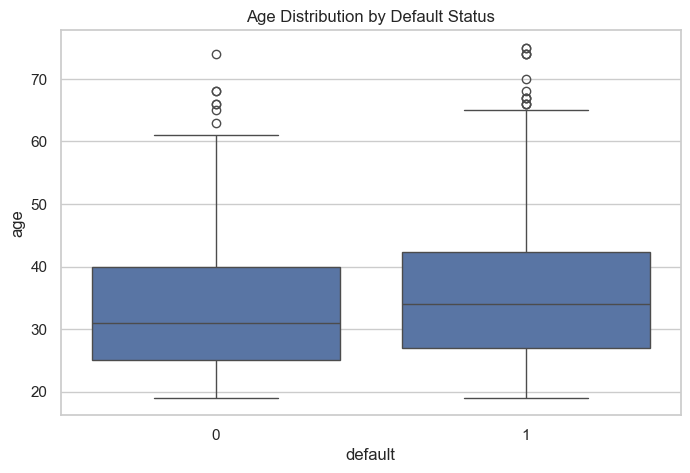

In [7]:
plt.figure(figsize=(8,5))
sns.boxplot(x='default', y='age', data=df)
plt.title("Age Distribution by Default Status")
plt.show()

### Insight:
Younger applicants show slightly higher default rates.
Age may act as an important predictive feature in risk modeling.

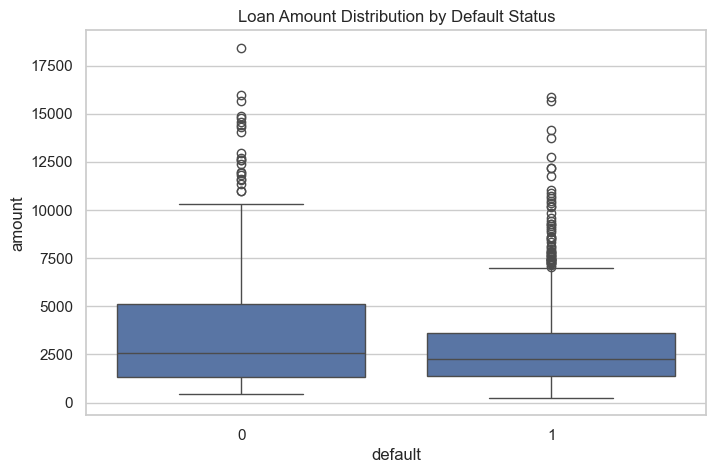

In [8]:
plt.figure(figsize=(8,5))
sns.boxplot(x='default', y='amount', data=df)
plt.title("Loan Amount Distribution by Default Status")
plt.show()

### Insight:
Higher loan amounts appear associated with increased default probability.
Large exposures may contribute to elevated risk levels.

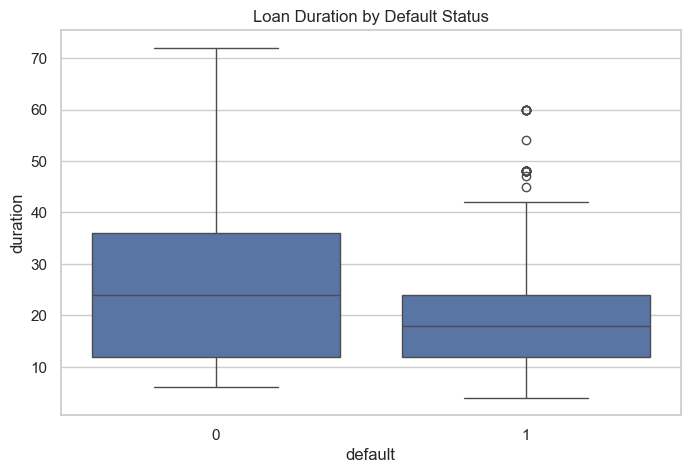

In [9]:
plt.figure(figsize=(8,5))
sns.boxplot(x='default', y='duration', data=df)
plt.title("Loan Duration by Default Status")
plt.show()

### Insight:
Longer loan durations show greater risk concentration.
Extended repayment periods may increase uncertainty and default likelihood.

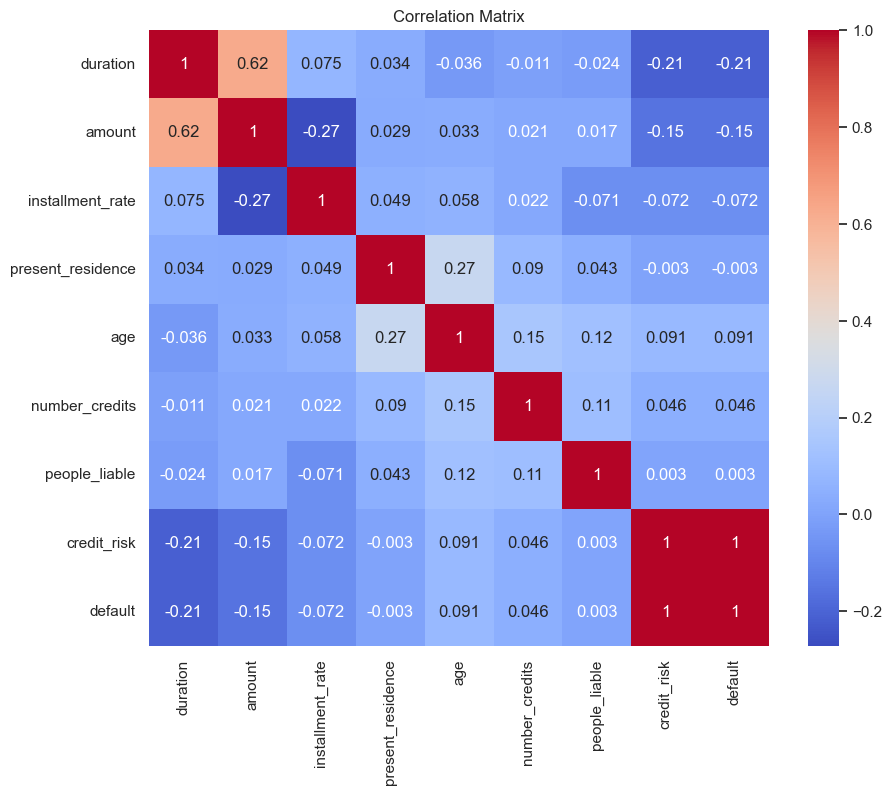

In [10]:
plt.figure(figsize=(10,8))
numeric_df = df.select_dtypes(include=['int64', 'float64'])
sns.heatmap(numeric_df.corr(), annot=True, cmap="coolwarm")
plt.title("Correlation Matrix")
plt.show()

### Insight:
Loan amount and duration show moderate positive correlation with default.
No severe multicollinearity observed among key numeric predictors.

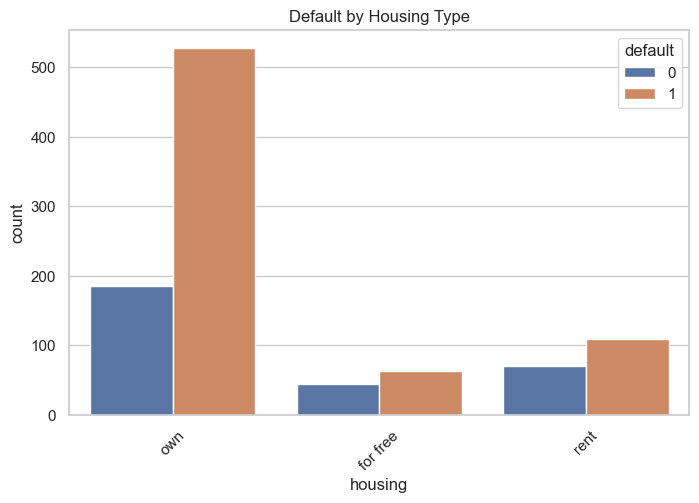

In [11]:
plt.figure(figsize=(8,5))
sns.countplot(x='housing', hue='default', data=df)
plt.title("Default by Housing Type")
plt.xticks(rotation=45)
plt.show()

### Insight:
Applicants living in rented or free housing arrangements show higher default tendencies compared to homeowners.
Housing stability may influence repayment behavior.

In [12]:
# Summary statistics grouped by default
df.groupby('default')[['age', 'amount', 'duration']].mean()

,age,amount,duration
default,,,
0,33.963333,3938.126667,24.860000
1,36.224286,2985.457143,19.207143


### Insight:
Defaulters exhibit higher average loan amounts and longer durations compared to non-defaulters.
This reinforces earlier visual findings that loan size and repayment length contribute to default risk.

In [13]:
df.isnull().sum()

status                     0
duration                   0
credit_history             0
purpose                    0
amount                     0
savings                    0
employment_duration        0
installment_rate           0
personal_status_sex        0
other_debtors              0
present_residence          0
property                   0
age                        0
other_installment_plans    0
housing                    0
number_credits             0
job                        0
people_liable              0
telephone                  0
foreign_worker             0
credit_risk                0
default                    0
dtype: int64

### Missing Value Analysis:
The dataset contains no missing values.
This ensures modeling can proceed without imputation-related bias.